# Vectorized aCCFs

This is a notebook to show how to use the algorithmic climate change functions (aCCFs) to complement the CoCiP output and the CO2 emissions to calculate a more complete climate impact of flights, including NOx and H2O effects.

## Installation
```
uv venv --python 3.11
source .venv/bin/activate
uv pip install -e .
uv pip install netcdf4
uv pip install matplotlib
uv pip install cartopy
uv pip install seaborn
uv pip install cdsapi

# DO NOT !!! uv pip install git+https://github.com/dlr-pa/climaccf.git
```

## References

Van Manen, J., and V. Grewe. “Algorithmic Climate Change Functions for the Use in Eco-Efficient Flight Planning.” Transportation Research Part D: Transport and Environment 67 (February 2019): 388–405. https://doi.org/10.1016/j.trd.2018.12.016.

Yin, Feijia, Volker Grewe, Federica Castino, et al. “Predicting the Climate Impact of Aviation for En-Route Emissions: The Algorithmic Climate Change Function Submodel ACCF 1.0 of EMAC 2.53.” Geoscientific Model Development 16, no. 11 (2023): 3313–34. https://doi.org/10.5194/gmd-16-3313-2023.

Dietmüller, Simone, Sigrun Matthes, Katrin Dahlmann, et al. “A Python Library for Computing Individual and Merged Non-CO 2 Algorithmic Climate Change Functions: CLIMaCCF V1.0.” Geoscientific Model Development 16, no. 15 (2023): 4405–25. https://doi.org/10.5194/gmd-16-4405-2023.

Matthes, Sigrun, Simone Dietmüller, Katrin Dahlmann, et al. “Updated Algorithmic Climate Change Functions (aCCF) V1.0A: Evaluation with the Climate-Response Model AirClim V2.0.” Preprint, Atmospheric sciences, 2023. https://doi.org/10.5194/gmd-2023-92.

Dahlmann, Katrin, Sigrun Matthes, and Volker Grewe. “Conversion of Climate Metrics for Policy Applications.” Preprint, Zenodo, July 31, 2025. https://doi.org/10.5281/ZENODO.16355781.

Smretschnig, Jakob, Feijia Yin, Dennis Piontek, et al. “Can We Achieve Significant Climate Mitigation by Optimising Only for Contrails?” Preprint, Interdependency modelling and green flight, July 28, 2026. https://doi.org/10.5194/jecats-2026-13.


## aCCF formulations
### $NO_x$ aCCFs
$ aCCF_{NO_x} = aCCF_{O_3} + aCCF_{CH_4} + aCCF_{PMO}$ in $[K \ kg(NO_2)^{-1}]$


$ aCCF_{O_3} = f_{O_3}(T, \Phi) $ in $[K \ kg(NO_2)^{-1}]$

$ aCCF_{CH_4} = f_{CH_4}(F_{in}, \Phi) $ in $[K \ kg(NO_2)^{-1}]$

$ aCCF_{PMO} = f_{PMO}(F_{in}, \Phi) $ in $[K \ kg(NO_2)^{-1}]$

### $H_2O$ aCCFs
$ aCCF_{H_2O} = f_{H_2O}(PV) $ in $[K \ kg(fuel)^{-1}]$


### Contrails aCCFs
$ aCCF_{dCont} = f_{dCont}(OLR) $ in $[K \ km(contrail)^{-1}]$

$ aCCF_{nCont} = f_{nCont}(T) $ in $[K \ km(contrail)^{-1}]$

# Imports

In [1]:
# import the new aCCF version
from pycontrails.models.accf_vectorized import ACCF, ACCFParams
from pycontrails.models.cocip import Cocip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pycontrails.core.flight import Flight
from pycontrails.core.met import MetDataset
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.datalib import ecmwf
from pycontrails import DiskCacheStore

# Set domain

In [ ]:
time_bounds = ("2023-03-19T15:00:00", "2023-03-20T15:00:00")
pressure_levels = [
    1000, 950, 900, 850, 800, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250,
    225, 200, 175, 150
]

# Download meteorology

In [ ]:
# pressure level data
era5_pl = ERA5(
    time=time_bounds,
    variables=Cocip.met_variables + Cocip.optional_met_variables + (ACCF.met_variables[2], ACCF.met_variables[4]),
    pressure_levels=pressure_levels,
    product_type="reanalysis",
)

# single level data (radiation)
era5_sl = ERA5(
    time=time_bounds,
    variables=Cocip.rad_variables + (ecmwf.SurfaceSolarDownwardRadiation,),
    product_type="reanalysis",
)

met = era5_pl.open_metdataset()
rad = era5_sl.open_metdataset()

# Create example flight

In [ ]:
from pycontrails.core import airports
from pycontrails import Flight

dep_lat, dep_lon = airports.global_airport_database().query("icao_code == 'EHAM'").iloc[0][["latitude", "longitude"]].values
des_lat, des_lon = airports.global_airport_database().query("icao_code == 'KJFK'").iloc[0][["latitude", "longitude"]].values
dep_time = "2023-03-19T15:00:00"
des_time = "2023-03-19T23:30:00"

dep_alt = 10000 # m
des_alt = 11600 # m

flight = Flight(
    longitude=[dep_lon, des_lon],
    latitude=[dep_lat, des_lat],
    altitude=[dep_alt, des_alt],
    time=pd.to_datetime([
        pd.Timestamp(dep_time),
        pd.Timestamp(des_time)
    ]),
    attrs={
        "flight_id": "Test-ACCF-123",
        "aircraft_type": "A359",
    }
)
flight = flight.resample_and_fill(freq="1min") # fill trajectory
flight

Flight [4 keys x 511 length, 2 attributes]
	Keys: longitude, latitude, altitude, time
	Attributes:
	time                [2023-03-19 15:00:00, 2023-03-19 23:30:00]
	longitude           [-73.779, 4.764]
	latitude            [40.639, 55.094]
	altitude            [10000.0, 11600.0]
	flight_id           Test-ACCF-123
	aircraft_type       A359

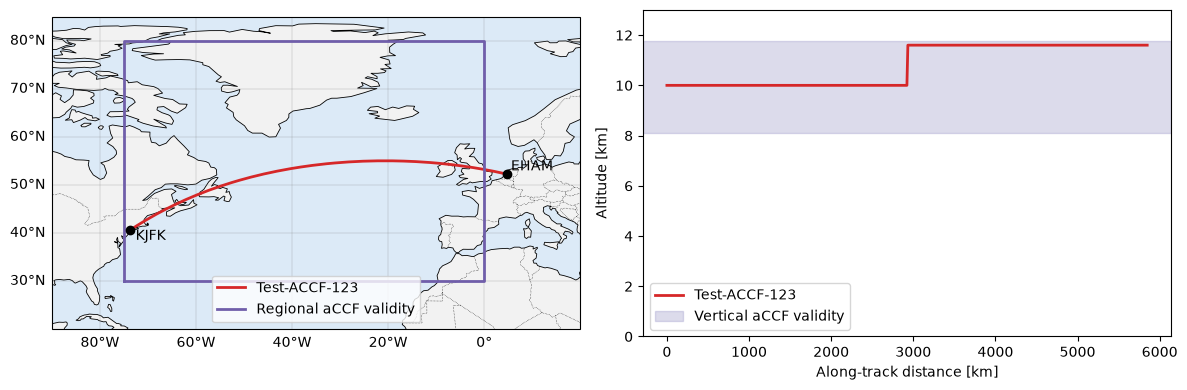

In [5]:
# Plot: horizontal (map) + vertical profile, side by side
# Along-track distance [km]; segment_length() returns metres, last value is NaN
seg = flight.segment_length()
dist_km = np.concatenate([[0.0], np.cumsum(seg[:-1])]) / 1e3
alt_km = flight["altitude"] / 1e3

fig = plt.figure(figsize=(12, 4))
proj = ccrs.PlateCarree()

# --- Left: horizontal profile (map) ---
ax_map = fig.add_subplot(1, 2, 1, projection=proj)
ax_map.set_extent([-90, 20, 20, 85], crs=proj)
ax_map.add_feature(cfeature.LAND, facecolor="0.95")
ax_map.add_feature(cfeature.OCEAN, facecolor="#dceaf7")
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.6)
gl.top_labels = False
gl.right_labels = False

ax_map.plot(
    flight["longitude"], flight["latitude"],
    color="tab:red", lw=2, transform=proj, label=flight.attrs["flight_id"],
)
ax_map.scatter(
    flight["longitude"][[0, -1]], flight["latitude"][[0, -1]],
    color="k", zorder=5, transform=proj,
)
ax_map.text(dep_lon + 0.8, dep_lat + 0.8, "EHAM", transform=proj)
ax_map.text(des_lon + 1.2, des_lat - 2.0, "KJFK", transform=proj)

# aCCF validity
lon_min = -75
lon_max = 0
lat_min = 30
lat_max = 80
ax_map.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color=sns.color_palette("Purples")[4], linewidth=2,
    transform=ccrs.PlateCarree(),
    label="Regional aCCF validity"
)

# --- Right: vertical profile ---
ax_vert = fig.add_subplot(1, 2, 2)
ax_vert.plot(dist_km, alt_km, color="tab:red", lw=2, label=flight.attrs["flight_id"])
ax_vert.set_xlabel("Along-track distance [km]")
ax_vert.set_ylabel("Altitude [km]")
ax_vert.set_ylim(0, 13)

# aCCF validity: 200-350 hPa, which is ~8.1km to 11.8km for the standard atmosphere
ax_vert.axhspan(8.117, 11.785, alpha=0.3, color=sns.color_palette("Purples")[3], label="Vertical aCCF validity")

fig.tight_layout()
ax_map.legend()
ax_vert.legend()
plt.show()

# Simulate aircraft performance, emissions, and CoCiP
- Fuel burn, NOx emissions, and contrail EF are needed in a later step to compute the total climate impact in kg(CO2e)

In [ ]:
from pycontrails.models.ps_model import PSFlight
from pycontrails.models.humidity_scaling import ExponentialBoostHumidityScaling
from pycontrails.models.emissions import Emissions
from pycontrails.models.cocip import Cocip

# Teoh et al. (2022)
humidity_scaling = ExponentialBoostHumidityScaling(
    rhi_adj=0.9779,
    rhi_boost_exponent=1.635,
    clip_upper=1.65,
)

# Aircraft performance calculation using Poll-Schumann
ps_model = PSFlight(met=met, params={
    "fill_low_altitude_with_isa_temperature": True,
    "fill_low_altitude_with_zero_wind": True
})
flight = ps_model.eval(flight)

# Emissions calculation
emissions_model = Emissions(met=met, params={
    "humidity_scaling": humidity_scaling,
})
flight = emissions_model.eval(flight)
flight.update(nox=flight["fuel_burn"] * flight["nox_ei"])

# CoCiP calculation
cocip_params = {
    "dt_integration": np.timedelta64(1, "m") , # Eichinger et al. (2025)
    "max_age": np.timedelta64(12, "h"), # Eichinger et al. (2025)
    "humidity_scaling": humidity_scaling, # Teoh et al. (2022)
}
cocip_sim = Cocip(met=met, rad=rad, params=cocip_params)
flight = cocip_sim.eval(flight)

# Evaluate aCCFs along trajectory

In [7]:
# Initialize the aCCF model
accf_model = ACCF(
    met=met,
    surface=rad,
    version="MATTHES_2023",
    efficacy="DAHLMANN_2025",
    include_pmo=True,
)
# Evaluate aCCF along the flight trajectory
flight = accf_model.eval(flight)
flight

/Users/jsmretschnig/sourcetree/pycontrails-fork/pycontrails/models/accf_vectorized.py:364: UserWarning: 
                    Note that only 94.1% of all cruise flight segments
                    could be evaluated for their climate effect using the aCCFs due to their limited validity.
                    
  warnings.warn(


Flight [77 keys x 511 length, 42 attributes]
	Keys: waypoint, longitude, latitude, altitude, time, ..., in_vertical_bounds
	Attributes:
	time                [2023-03-19 15:00:00, 2023-03-19 23:30:00]
	longitude           [-73.779, 4.764]
	latitude            [40.639, 55.094]
	altitude            [10000.0, 11600.0]
	flight_id           Test-ACCF-123
	aircraft_type       A359
	engine_deterioration_factor0.025
	aircraft_performance_modelPS
	aircraft_type_ps    A359
	n_engine            2
	wingspan            64.75
	max_mach            0.89
	max_altitude        13136.900000976
	aircraft_role       Passenger
	n_seats             306
	passenger_load_factor0.8077741935483871
	cargo_load_factor   0.37192365697074675
	payload             32584.075667511937
	total_fuel_burn     43420.702012060865
	rhi_adj             0.9779
	rhi_boost_exponent  1.635
	clip_upper          1.65
	engine_uid          01P18RR124
	engine_uid_used     01P18RR124
	gaseous_data_source FFM2
	nvpm_data_source    ICAO EDB (T4/T2)
	total_co2           137165.99765610025
	total_h2o           53407.46347483486
	total_so2           52.104842414473026
	total_sulphates     1.0633641309076127
	total_oc            0.8684140402412172
	total_nox           666.0768423886186
	total_co            33.843004822561255
	total_hc            0.008677693544246468
	total_nvpm_mass     3.237644914474017
	total_nvpm_number   3.560203601948478e+19
	humidity_scaling_nameexponential_boost
	humidity_scaling_formularhi -> (rhi / rhi_adj) ^ rhi_boost_exponent
	humidity_scaling_rhi_adj0.9779
	humidity_scaling_rhi_boost_exponent1.635
	humidity_scaling_clip_upper1.65
	pycontrails_version 0.1.dev2851
	h2o_pulse_atr20     1.510088844069821e-11
	o3_pulse_atr20      1.531311010174149e-10
	ch4_pulse_atr20     -1.9093173884486094e-11
	nox_pulse_atr20     1.3403792713292879e-10

# Conversion to common climate metric

In [8]:
# Convert CoCiP output (EF) to P-ATR20 (K)
from pycontrails.physics import constants

def global_yearly_mean_rf(ef):
    return (ef / constants.surface_area_earth / constants.seconds_per_year)

contrail_efficacy = ACCFParams.efficacy_factors["DAHLMANN_2025"]["CiC"]
print(f"Contrail efficacy: {contrail_efficacy}")

ef = flight["ef"].sum()

# unclear if 0.0151 (Yin et al. 2023 supplement) or 0.0065 (Dahlmann et al. 2025 preprint) to get from RF to P-ATR20
flight.attrs["cocip_pulse_atr20"] = global_yearly_mean_rf(ef) * 0.0065 * contrail_efficacy

Contrail efficacy: 0.21


In [9]:
# Convert to CO2e (ATR20)
AGWP_CO2_PULSE_ATR20 = 5.56e-16 # [K / kg(CO2)], Dahlmann et al. (2025)

results = {
    "CO2": flight.attrs["total_co2"],
    "Contrails": flight.attrs["cocip_pulse_atr20"] / AGWP_CO2_PULSE_ATR20,
    "O3": flight.attrs["o3_pulse_atr20"] / AGWP_CO2_PULSE_ATR20,
    "CH4": flight.attrs["ch4_pulse_atr20"] / AGWP_CO2_PULSE_ATR20,
    "NOx": flight.attrs["nox_pulse_atr20"] / AGWP_CO2_PULSE_ATR20,
    "H2O": flight.attrs["h2o_pulse_atr20"] / AGWP_CO2_PULSE_ATR20,
}
print(results)

{'CO2': np.float64(137165.99765610025), 'Contrails': np.float64(98180.00378864536), 'O3': np.float64(275415.6493118973), 'CH4': np.float64(-34340.24079943542), 'NOx': np.float64(241075.40851246187), 'H2O': np.float64(27159.871296219804)}


In [10]:
# Convert to CO2e (ATR100)
AGWP_CO2_PULSE_ATR100 = 5.148e-16 # [K / kg(CO2)], Dahlmann et al. (2025)

# Conversion factors from P-ATR20 to P-ATR100
# Dahlmann et al. (2025), Table 3
cf = {
    "Contrails": 0.0016 / 0.0065,
    "O3": 0.0082 / 0.0337,
    "CH4": 0.1059 / 0.2838,
    "H2O": 0.0078 / 0.0320,
}

results_100 = {
    "CO2": flight.attrs["total_co2"],
    "Contrails": flight.attrs["cocip_pulse_atr20"] * cf["Contrails"] / AGWP_CO2_PULSE_ATR100,
    "O3": flight.attrs["o3_pulse_atr20"] * cf["O3"] / AGWP_CO2_PULSE_ATR100,
    "CH4": flight.attrs["ch4_pulse_atr20"] * cf["CH4"] / AGWP_CO2_PULSE_ATR100,
    "NOx": None, 
    "H2O": flight.attrs["h2o_pulse_atr20"] * cf["H2O"] / AGWP_CO2_PULSE_ATR100,
}
results_100["NOx"] = results_100["O3"] + results_100["CH4"]
print(results_100)

{'CO2': np.float64(137165.99765610025), 'Contrails': np.float64(26101.527514906134), 'O3': np.float64(72378.37334442358), 'CH4': np.float64(-13839.587904626833), 'NOx': np.float64(58538.78543979675), 'H2O': np.float64(7150.041875330592)}


# Visualization

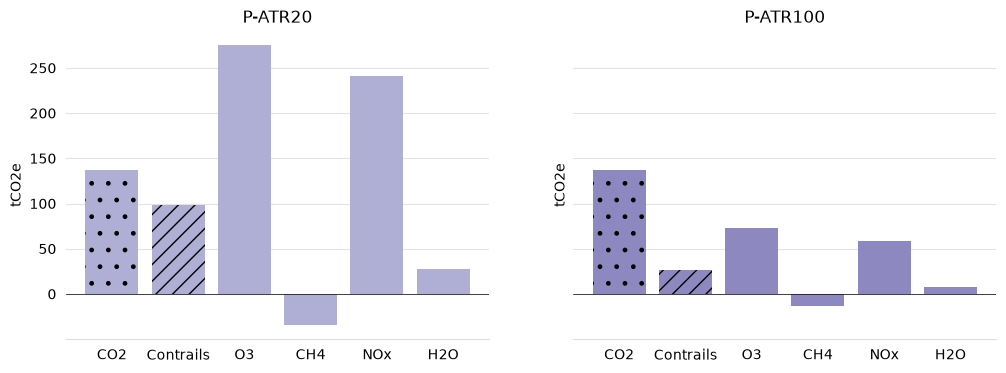

In [11]:
import matplotlib.pyplot as plt

labels1 = results.keys()
values1 = np.array(list(results.values())) / 1e3

labels2 = results_100.keys()
values2 = np.array(list(results_100.values())) / 1e3

fig, (ax1, ax2) = plt.subplots(figsize=(12, 4), ncols=2, nrows=1, sharey=True)

### P-ATR20
ax1.bar(labels1, values1, color=sns.color_palette("Purples")[2], hatch=[".", "//", None, None, None, None])
ax1.set_ylabel("tCO2e")
ax1.grid(axis="y", alpha=0.8)
ax1.set_axisbelow(True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#DDDDDD')

ax1.tick_params(bottom=False, left=False)

ax1.axhline(0, linewidth=0.5, color="black")

ax1.set_axisbelow(True)
ax1.yaxis.grid(True, color='#DDDDDD')
ax1.xaxis.grid(False)
ax1.set_title("P-ATR20")

### P-ATR100
ax2.bar(labels2, values2, color=sns.color_palette("Purples")[3], hatch=[".", "//", None, None, None, None])
ax2.set_ylabel("tCO2e")
ax2.grid(axis="y", alpha=0.8)
ax2.set_axisbelow(True)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_color('#DDDDDD')

ax2.tick_params(bottom=False, left=False)

ax2.axhline(0, linewidth=0.5, color="black")

ax2.set_axisbelow(True)
ax2.yaxis.grid(True, color='#DDDDDD')
ax2.xaxis.grid(False)
ax2.set_title("P-ATR100")

plt.show()

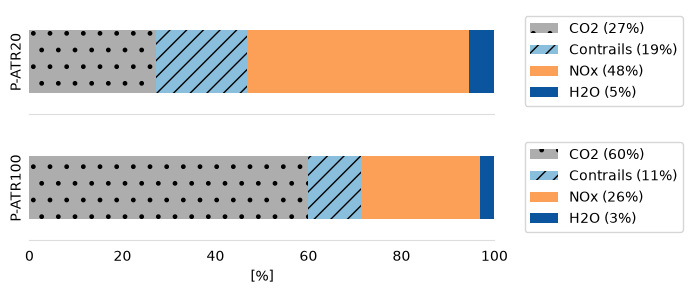

In [ ]:
import seaborn as sns

keys_to_keep = ["CO2", "Contrails", "NOx", "H2O"]
fig, axes = plt.subplots(figsize=(6, 3), ncols=1, nrows=2, sharex=True)

for r, ax, label in zip([results, results_100], axes, ["P-ATR20", "P-ATR100"]):
    data = {k: v for k, v in r.items() if k in keys_to_keep}
    colors = [sns.color_palette("Grays")[2], sns.color_palette("Blues")[2], sns.color_palette("Oranges")[2], sns.color_palette("Blues")[5]]
    hatches = [".", "//", "", ""]
    total = sum(data.values())
    
    left = 0
    for i, (k, v) in enumerate(data.items()):
        pct = v / total * 100
        ax.barh(0, pct, left=left, height=0.6, color=colors[i], label=f"{k} ({pct:.0f}%)", hatch=hatches[i])
        left += pct

    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_ylim(-0.5, 0.5)
    ax.set_ylabel(label)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')

    ax.tick_params(bottom=False, left=False)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='#DDDDDD')
    ax.xaxis.grid(False)

    ax.legend(bbox_to_anchor=(1.05, 1))

axes[1].set_xlabel("[%]")

plt.yticks([])
plt.show()

# Grid mode

In [13]:
# Initialize the aCCF model
accf_model = ACCF(
    met=met,
    surface=rad,
    version="MATTHES_2023",
    efficacy="DAHLMANN_2025",
    include_pmo=True,
)
# Evaluate aCCF on the grid
grid = accf_model.eval()
grid

/Users/jsmretschnig/sourcetree/pycontrails-fork/pycontrails/models/accf_vectorized.py:310: UserWarning: 
                Note that the following validity bounds were applied:
                latitude: (30.0, 80.0)
                longitude: (-75.0, 0.0)
                level: (200.0, 350.0)
                
  warnings.warn(


MetDataset with data:

<xarray.Dataset> Size: 575MB
Dimensions:                              (longitude: 301, latitude: 201,
                                          level: 5, time: 25)
Coordinates:
  * longitude                            (longitude) float64 2kB -75.0 ... 0.0
  * latitude                             (latitude) float64 2kB 30.0 ... 80.0
  * level                                (level) float64 40B 200.0 ... 350.0
    air_pressure                         (level) float64 40B 2e+04 ... 3.5e+04
    altitude                             (level) float64 40B 1.178e+04 ... 8....
  * time                                 (time) datetime64[ns] 200B 2023-03-1...
    expver                               (time) <U4 400B '0001' ... '0001'
    number                               int64 8B 0
Data variables: (12/15)
    air_temperature                      (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    specific_humidity                    (longitude, latitude, level, time) float32 30MB ...
    eastward_wind                        (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    northward_wind                       (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    lagrangian_tendency_of_air_pressure  (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    specific_cloud_ice_water_content     (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    ...                                   ...
    relative_humidity                    (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    tau_cirrus                           (longitude, latitude, level, time) float32 30MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    aCCF_H2O                             (longitude, latitude, level, time) float64 61MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    aCCF_O3                              (longitude, latitude, level, time) float64 61MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    aCCF_CH4                             (longitude, latitude, level, time) float64 61MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
    aCCF_NOx                             (longitude, latitude, level, time) float64 61MB dask.array<chunksize=(60, 201, 4, 1), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-27T09:43 GRIB to CDM+CF via cfgrib-0.9.1...
    pycontrails_version:     0.1.dev2851
    provider:                ECMWF
    dataset:                 ERA5
    product:                 reanalysis

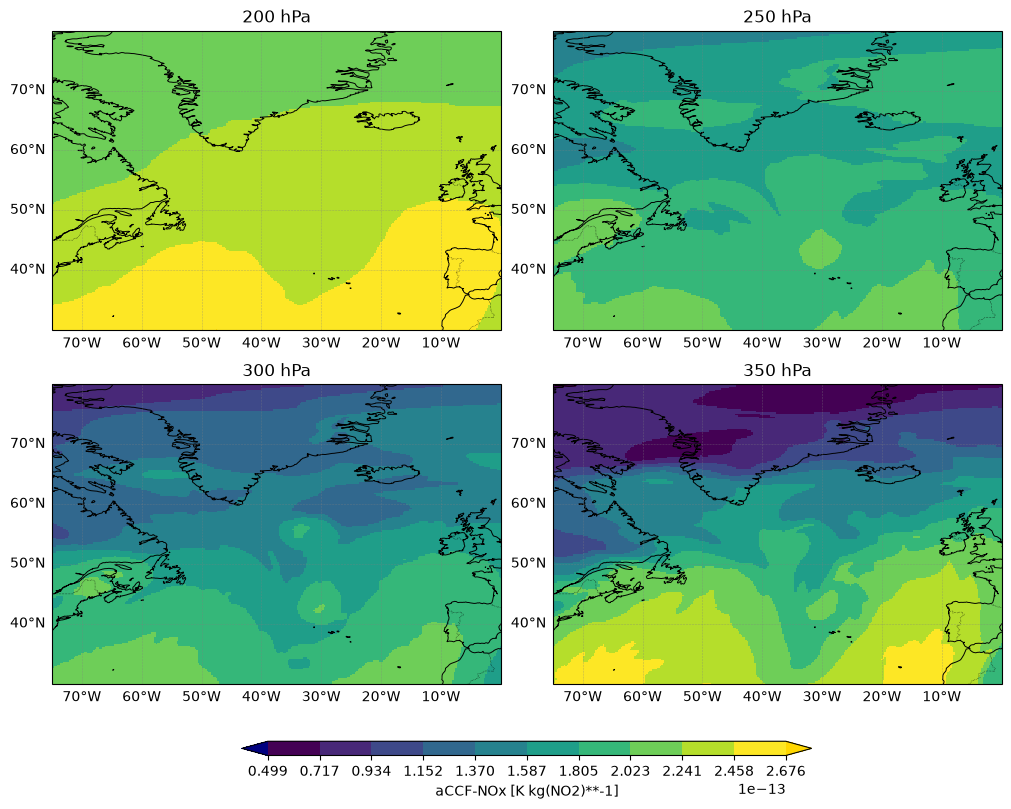

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da = grid.data["aCCF_NOx"].isel(time=0).sel(level=[200, 250, 300, 350])
da = da.transpose("level", "latitude", "longitude")
levels = da["level"].values

bounds = np.linspace(float(da.min()), float(da.max()), 11)
label = f"{da.attrs.get('short_name', 'var')} [{da.attrs.get('units', '')}]"

cmap = plt.get_cmap("viridis", len(bounds) - 1).copy()
cmap.set_under("navy")
cmap.set_over("gold")
norm = mpl.colors.BoundaryNorm(bounds, ncolors=cmap.N, extend="neither")

data_crs = ccrs.PlateCarree()
extent = [float(da.longitude.min()), float(da.longitude.max()),
          float(da.latitude.min()), float(da.latitude.max())]

fig, ax = plt.subplots(
    2, 2, figsize=(10, 8),
    subplot_kw={"projection": data_crs},
    constrained_layout=True,
)
ax = ax.flatten()

for i, lev in enumerate(levels):
    cax = da.sel(level=lev).plot.pcolormesh(
        ax=ax[i], x="longitude", y="latitude", transform=data_crs,
        cmap=cmap, norm=norm, add_colorbar=False, rasterized=True,
    )

    ax[i].set_title(f"{lev:g} hPa")
    ax[i].set_extent(extent, crs=data_crs)
    ax[i].coastlines(resolution="50m", linewidth=0.7)
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")

    gl = ax[i].gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

cb = fig.colorbar(
    cax, ax=ax, orientation="horizontal", label=label,
    ticks=bounds, extend="both", spacing="uniform",
    shrink=0.6, pad=0.05, aspect=40,
)

plt.show()

# Compare with CLIMaCCF

In [17]:
from pycontrails.models.accf import ACCF as CLIMACCF

climaccf = CLIMACCF(
    met=met,
    surface=rad,
    lat_bound=[30.0, 80.0],
    lon_bound=[-75.0, 0.0],
    efficacy=False, # to be applied manually
    # efficacy_option: str = "lee_2021"
    accf_v="V1.0A",
    emission_scenario="pulse",
    time_horizon=20,
    PMO=True,
    merged=False,
)
# flight = climaccf.eval(flight) # TODO